In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# نشوف الفولدرات اللي في MyDrive
print("محتوى MyDrive:")
print(os.listdir('/content/drive/MyDrive'))

محتوى MyDrive:
['Classroom', 'IMG_20200122_234908.jpg', 'IMG-20220801-WA0128.jpg', 'IMG-20220801-WA0130.jpg', 'photo_blur81.png', 'IMG-20221211-WA0058.jpg', '20240528_154648.heic', '0xCairo Tech Day II.pkpass', 'images.jpeg', 'images-1.jpeg', 'Screenshot_20241110_233927_WhatsApp.jpg', 'Screenshot_20241110_233916_WhatsApp.jpg', 'Green and Gold Vintage Festive Christmas Raffle Ticket.pdf', 'بحث.pdf', 'Computer Networks 1 for mid-term.pdf', 'مادة لاهوت المقارن.pdf', 'مادة العقيدة.pdf', 'Colab Notebooks', 'أسماء الطلاب ورقم المسلسل الخاص بكل طالب.pdf', 'البلطة.docx', 'زيارات.pdf', 'كون مستعد.pdf', 'https:  drive.g.txt', 'https:  docs.go.txt', '1  Virtual memory.docx', 'أوراق شخصية-compressed.pdf', 'شيت رحلة براعم - قائد شفتان ايفا منير.xlsx', 'Cover letter_250729_024544.pdf', 'عاوزة النص من الصورة دي.gsheet', 'النحو - مراكم لن يراكم.gdoc', 'جدول بيانات بدون عنوان.gsheet', 'بينات القادة.gsheet', 'Emily_Wael_CV (11).pdf', 'Emily_Wael_CV (10).pdf', 'Emily_Wael_CV (9).pdf', 'Emily_Wael_CV (

In [ ]:
import os

drive_path = '/content/drive/MyDrive/ Oral_Disease_Project'  # لاحظي المسافة قبل O
print(os.listdir(drive_path))

['archive (27).zip']


In [ ]:
import zipfile

drive_path = '/content/drive/MyDrive/ Oral_Disease_Project'
zip_path = f'{drive_path}/archive (27).zip'
extract_path = '/content/oral_diseases_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("تم فك الضغط ✅")

تم فك الضغط ✅


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        sub_indent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{sub_indent}{f}')
        if len(files) > 3:
            print(f'{sub_indent}... ({len(files)} files total)')

oral_diseases_data/
  hypodontia/
    hypodontia/
      (948).JPG
      (1007).JPG
      (125).jpg
      ... (1251 files total)
  Tooth Discoloration/
    Tooth Discoloration /
      Tooth_discoloration_augmented_dataser/
        preview/
      tooth discoloration original dataset/
        tooth discoloration original dataset/
  Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/
    Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/
      Data/
        labels/
          val/
          train/
        images/
          val/
          train/
  Data caries/
    Data caries/
      caries augmented data set/
        preview/
      caries orignal data set/
        done/
  Calculus/
    Calculus/
      (177).jpg
      (175).jpg
      (125).jpg
      ... (1296 files total)
  Mouth Ulcer/
    Mouth Ulcer/
      Mouth_Ulcer_augmented_DataSet/
        preview/
      ulcer original dataset/
        ulcer original dataset/
  Gingivitis/
    Gingivitis/
      (177).jpg

In [ ]:
import os

base = '/content/oral_diseases_data'

class_folders = {
    'Calculus': f'{base}/Calculus/Calculus',
    'Gingivitis': f'{base}/Gingivitis/Gingivitis',
    'Hypodontia': f'{base}/hypodontia/hypodontia',
    'Data_Caries': f'{base}/Data caries/Data caries',
    'Mouth_Ulcer': f'{base}/Mouth Ulcer/Mouth Ulcer',
    'Tooth_Discoloration': f'{base}/Tooth Discoloration/Tooth Discoloration ',
}

image_exts = ('.jpg', '.jpeg', '.png')

class_files = {}
for cls, folder in class_folders.items():
    all_files = []
    for root, dirs, files in os.walk(folder):
        # نستبعد أي فولدر فيه augmented أو preview لتجنب data leakage
        if 'augmented' in root.lower() or 'preview' in root.lower():
            continue
        for f in files:
            if f.lower().endswith(image_exts):
                all_files.append(os.path.join(root, f))
    class_files[cls] = all_files
    print(f"{cls}: {len(all_files)} صورة")

print(f"\nإجمالي الصور: {sum(len(v) for v in class_files.values())}")

Calculus: 1296 صورة
Gingivitis: 2349 صورة
Hypodontia: 1251 صورة
Data_Caries: 219 صورة
Mouth_Ulcer: 265 صورة
Tooth_Discoloration: 183 صورة

إجمالي الصور: 5563


In [ ]:
!pip install split-folders -q

In [ ]:
import splitfolders
import shutil
import os

# هنعمل فولدر منظم فيه كل فئة لوحدها الأول (مطلوب لـ split-folders)
organized_path = '/content/organized_data'
os.makedirs(organized_path, exist_ok=True)

for cls, files in class_files.items():
    cls_folder = os.path.join(organized_path, cls)
    os.makedirs(cls_folder, exist_ok=True)
    for i, filepath in enumerate(files):
        ext = os.path.splitext(filepath)[1]
        dest = os.path.join(cls_folder, f"{cls}_{i}{ext}")
        shutil.copy(filepath, dest)

print("تم تنظيم الصور ✅")
for cls in class_files.keys():
    n = len(os.listdir(os.path.join(organized_path, cls)))
    print(f"{cls}: {n} صورة")

تم تنظيم الصور ✅
Calculus: 1296 صورة
Gingivitis: 2349 صورة
Hypodontia: 1251 صورة
Data_Caries: 219 صورة
Mouth_Ulcer: 265 صورة
Tooth_Discoloration: 183 صورة


In [ ]:
# دلوقتي نقسم لـ train/val/test
splitfolders.ratio(
    organized_path,
    output='/content/split_data',
    seed=42,
    ratio=(0.8, 0.1, 0.1)  # 80% train, 10% val, 10% test
)

print("تم التقسيم ✅")

Copying files: 5563 files [00:01, 2892.62 files/s]

تم التقسيم ✅


In [ ]:
# تأكيد التقسيم
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}:")
    split_path = f'/content/split_data/{split}'
    for cls in os.listdir(split_path):
        n = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {cls}: {n}")


TRAIN:
  Mouth_Ulcer: 212
  Tooth_Discoloration: 146
  Calculus: 1036
  Data_Caries: 175
  Hypodontia: 1000
  Gingivitis: 1879

VAL:
  Mouth_Ulcer: 26
  Tooth_Discoloration: 18
  Calculus: 129
  Data_Caries: 21
  Hypodontia: 125
  Gingivitis: 234

TEST:
  Mouth_Ulcer: 27
  Tooth_Discoloration: 19
  Calculus: 131
  Data_Caries: 23
  Hypodontia: 126
  Gingivitis: 236


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # مقاس قياسي يناسب MobileNet/EfficientNet/ResNet كمان
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# الـ val والـ test من غير augmentation، rescale بس
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/split_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/split_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/split_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# مهم: نحفظ ترتيب الفئات عشان نستخدمه في الـ deployment app بعدين
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
print("Class mapping:", class_indices)

Found 4448 images belonging to 6 classes.
Found 553 images belonging to 6 classes.
Found 562 images belonging to 6 classes.
Class mapping: {'Calculus': 0, 'Data_Caries': 1, 'Gingivitis': 2, 'Hypodontia': 3, 'Mouth_Ulcer': 4, 'Tooth_Discoloration': 5}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7155727155727156), 1: np.float64(4.236190476190476), 2: np.float64(0.3945361007628171), 3: np.float64(0.7413333333333333), 4: np.float64(3.49685534591195), 5: np.float64(5.077625570776256)}


In [ ]:
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=6):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [ ]:
history_cnn = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks_cnn
)

Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 597ms/step - accuracy: 0.3300 - loss: 1.6446 - val_accuracy: 0.0470 - val_loss: 3.6246 - learning_rate: 0.0010
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 74s 532ms/step - accuracy: 0.4323 - loss: 1.3973 - val_accuracy: 0.1013 - val_loss: 3.7158 - learning_rate: 0.0010
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 74s 534ms/step - accuracy: 0.4656 - loss: 1.3134 - val_accuracy: 0.0904 - val_loss: 4.9026 - learning_rate: 0.0010
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 536ms/step - accuracy: 0.5034 - loss: 1.2435 - val_accuracy: 0.2297 - val_loss: 2.5475 - learning_rate: 0.0010
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 527ms/step - accuracy: 0.5270 - loss: 1.1706 - val_accuracy: 0.4033 - val_loss: 1.7015 - learning_rate: 0.0010
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 528ms/step - accuracy: 0.5544 - loss: 1.1149 - val_accuracy: 0.2333 - val_loss: 4.1426 - learning_rate: 0.0010
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 74s 531ms/step - accuracy: 0.5

In [ ]:
test_loss, test_acc = custom_cnn.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.7135 - loss: 0.6314

Test Accuracy: 0.7135
Test Loss: 0.6314


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
Classification Report - Custom CNN

                     precision    recall  f1-score   support

           Calculus       0.55      0.81      0.65       131
        Data_Caries       0.50      0.43      0.47        23
         Gingivitis       0.83      0.57      0.68       236
         Hypodontia       0.83      0.90      0.86       126
        Mouth_Ulcer       0.85      0.81      0.83        27
Tooth_Discoloration       0.60      0.79      0.68        19

           accuracy                           0.71       562
          macro avg       0.69      0.72      0.70       562
       weighted avg       0.75      0.71      0.71       562



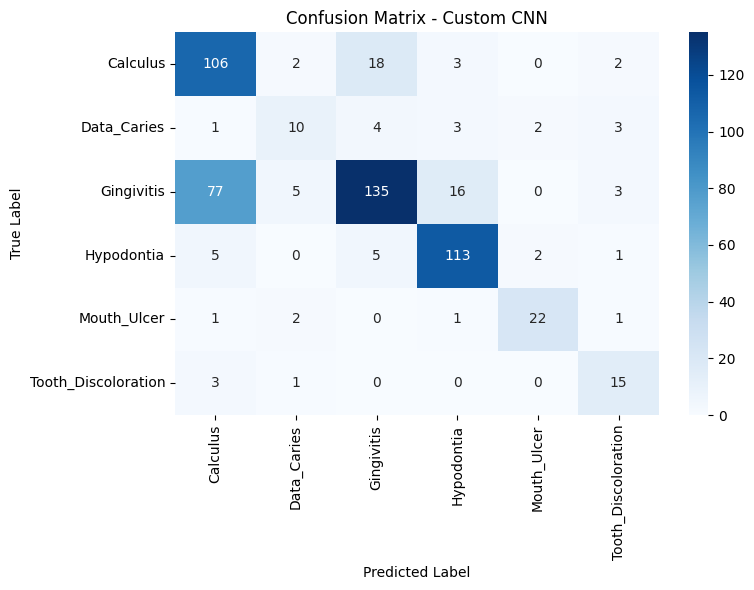

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# التنبؤ على test set
test_generator.reset()
y_pred_probs = custom_cnn.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report - Custom CNN\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Custom CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/cm_custom_cnn.png', dpi=150)
plt.show()

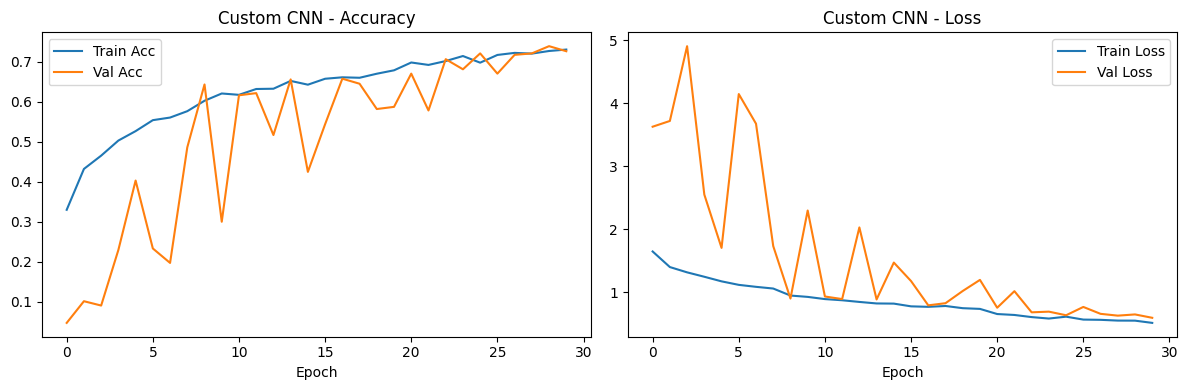

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.title('Custom CNN - Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('Custom CNN - Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('/content/history_custom_cnn.png', dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

def build_transfer_model(base_model_fn, input_shape=(224,224,3), num_classes=6):
    base_model = base_model_fn(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # نجمّد الـ base الأول (Feature Extraction phase)

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model

mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2)
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_mobilenet = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_mobilenet.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_mobilenet
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 637ms/step - accuracy: 0.5007 - loss: 1.2882 - val_accuracy: 0.6944 - val_loss: 0.7788 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 520ms/step - accuracy: 0.6097 - loss: 0.8956 - val_accuracy: 0.6709 - val_loss: 0.7846 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 511ms/step - accuracy: 0.6290 - loss: 0.8402 - val_accuracy: 0.6926 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 506ms/step - accuracy: 0.6720 - loss: 0.7391 - val_accuracy: 0.7215 - val_loss: 0.6673 - learning_rate: 0.0010
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.6686 - loss: 0.6884 - val_accuracy: 0.7016 - val_loss: 0.7256 - learning_rate: 0.0010
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 515ms/step - accuracy: 0.6922 - loss: 0.6471 - val_accuracy: 0.7107 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 508ms/step - accuracy: 0.

In [ ]:
# نفك تجميد الـ base model
mobilenet_base.trainable = True

# بس نجمد أول 100 layer ونسيب الباقي (آخر layers) قابلة للتدريب
fine_tune_at = 100
for layer in mobilenet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"عدد الـ layers القابلة للتدريب: {sum(1 for l in mobilenet_base.layers if l.trainable)}")

عدد الـ layers القابلة للتدريب: 54


In [ ]:
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # لاحظي: أقل بكتير من 0.001 الافتراضي
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_mobilenet_finetuned.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history_mobilenet_ft = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 600ms/step - accuracy: 0.5852 - loss: 1.0999 - val_accuracy: 0.7595 - val_loss: 0.5425 - learning_rate: 1.0000e-05
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 119s 527ms/step - accuracy: 0.6135 - loss: 0.7739 - val_accuracy: 0.7649 - val_loss: 0.5473 - learning_rate: 1.0000e-05
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.6371 - loss: 0.7173 - val_accuracy: 0.7577 - val_loss: 0.5521 - learning_rate: 1.0000e-05
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 521ms/step - accuracy: 0.6565 - loss: 0.6648 - val_accuracy: 0.7577 - val_loss: 0.5425 - learning_rate: 5.0000e-06
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 525ms/step - accuracy: 0.6740 - loss: 0.6251 - val_accuracy: 0.7414 - val_loss: 0.5386 - learning_rate: 5.0000e-06
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.6765 - loss: 0.6184 - val_accuracy: 0.7450 - val_loss: 0.5432 - learning_rate: 5.0000e-06
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 

In [ ]:
test_loss_mb, test_acc_mb = mobilenet_model.evaluate(test_generator)
print(f"\nMobileNetV2 Test Accuracy: {test_acc_mb:.4f}")
print(f"MobileNetV2 Test Loss: {test_loss_mb:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7794 - loss: 0.5557

MobileNetV2 Test Accuracy: 0.7794
MobileNetV2 Test Loss: 0.5557


18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 324ms/step
Classification Report - MobileNetV2

                     precision    recall  f1-score   support

           Calculus       0.65      0.74      0.69       131
        Data_Caries       0.52      0.61      0.56        23
         Gingivitis       0.81      0.74      0.78       236
         Hypodontia       0.95      0.91      0.93       126
        Mouth_Ulcer       1.00      0.93      0.96        27
Tooth_Discoloration       0.48      0.63      0.55        19

           accuracy                           0.78       562
          macro avg       0.74      0.76      0.74       562
       weighted avg       0.79      0.78      0.78       562



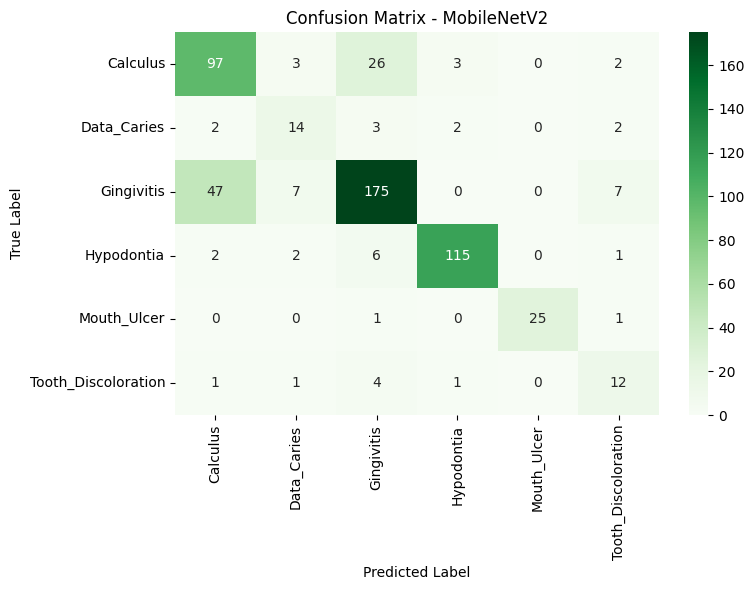

In [ ]:
test_generator.reset()
y_pred_probs_mb = mobilenet_model.predict(test_generator)
y_pred_mb = np.argmax(y_pred_probs_mb, axis=1)
y_true = test_generator.classes  # نفسه زي قبل، بس بنعرفه تاني للأمان

print("Classification Report - MobileNetV2\n")
print(classification_report(y_true, y_pred_mb, target_names=class_names))

cm_mb = confusion_matrix(y_true, y_pred_mb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_mb, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/cm_mobilenet.png', dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

efficientnet_model, efficientnet_base = build_transfer_model(EfficientNetB0)

efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
callbacks_eff = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_efficientnet.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_eff
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 116s 639ms/step - accuracy: 0.1369 - loss: 1.8387 - val_accuracy: 0.0325 - val_loss: 1.7916 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.1270 - loss: 1.7920 - val_accuracy: 0.0325 - val_loss: 1.7917 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 513ms/step - accuracy: 0.0506 - loss: 1.7928 - val_accuracy: 0.0470 - val_loss: 1.7933 - learning_rate: 0.0010
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 511ms/step - accuracy: 0.0443 - loss: 1.7919 - val_accuracy: 0.0470 - val_loss: 1.7926 - learning_rate: 0.0010
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 515ms/step - accuracy: 0.3017 - loss: 1.7919 - val_accuracy: 0.0325 - val_loss: 1.7918 - learning_rate: 5.0000e-04
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 514ms/step - accuracy: 0.0461 - loss: 1.7919 - val_accuracy: 0.0325 - val_loss: 1.7927 - learning_rate: 5.0000e-04


In [ ]:
train_datagen_eff = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
    # ملاحظة: من غير rescale خالص هنا
)

val_test_datagen_eff = ImageDataGenerator()  # من غير rescale برضو

train_generator_eff = train_datagen_eff.flow_from_directory(
    '/content/split_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator_eff = val_test_datagen_eff.flow_from_directory(
    '/content/split_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_eff = val_test_datagen_eff.flow_from_directory(
    '/content/split_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4448 images belonging to 6 classes.
Found 553 images belonging to 6 classes.
Found 562 images belonging to 6 classes.


In [ ]:
efficientnet_model, efficientnet_base = build_transfer_model(EfficientNetB0)

efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_eff = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_efficientnet.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_efficientnet = efficientnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_eff
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 109s 617ms/step - accuracy: 0.5647 - loss: 1.0992 - val_accuracy: 0.6799 - val_loss: 0.7680 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.6769 - loss: 0.7576 - val_accuracy: 0.7107 - val_loss: 0.7254 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 509ms/step - accuracy: 0.6996 - loss: 0.6511 - val_accuracy: 0.7125 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 506ms/step - accuracy: 0.7212 - loss: 0.6025 - val_accuracy: 0.7505 - val_loss: 0.5948 - learning_rate: 0.0010
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 505ms/step - accuracy: 0.7282 - loss: 0.5381 - val_accuracy: 0.6926 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 522ms/step - accuracy: 0.7421 - loss: 0.4885 - val_accuracy: 0.7595 - val_loss: 0.5544 - learning_rate: 0.0010
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 515ms/step - accuracy: 0.

In [ ]:
efficientnet_base.trainable = True

fine_tune_at = 100
for layer in efficientnet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"عدد الـ layers القابلة للتدريب: {sum(1 for l in efficientnet_base.layers if l.trainable)}")

عدد الـ layers القابلة للتدريب: 138


In [ ]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_eff_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_efficientnet_finetuned.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history_efficientnet_ft = efficientnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_eff_ft
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 147s 640ms/step - accuracy: 0.5569 - loss: 1.1109 - val_accuracy: 0.7197 - val_loss: 0.7577 - learning_rate: 1.0000e-05
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 76s 544ms/step - accuracy: 0.5940 - loss: 0.9153 - val_accuracy: 0.6655 - val_loss: 0.8143 - learning_rate: 1.0000e-05
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 541ms/step - accuracy: 0.6295 - loss: 0.7537 - val_accuracy: 0.6799 - val_loss: 0.7797 - learning_rate: 1.0000e-05
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 537ms/step - accuracy: 0.6500 - loss: 0.7433 - val_accuracy: 0.6854 - val_loss: 0.7718 - learning_rate: 5.0000e-06
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 539ms/step - accuracy: 0.6630 - loss: 0.7014 - val_accuracy: 0.6817 - val_loss: 0.7481 - learning_rate: 5.0000e-06
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 74s 536ms/step - accuracy: 0.6632 - loss: 0.6656 - val_accuracy: 0.6854 - val_loss: 0.7352 - learning_rate: 5.0000e-06
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 5

In [ ]:
from tensorflow.keras.models import load_model

# ده الملف اللي اتحفظ من الـ Phase الأولى (Feature Extraction) قبل ما نبدأ Fine-tuning
efficientnet_final = load_model('/content/best_efficientnet.keras')
print("تم تحميل أفضل نسخة من EfficientNetB0 ✅")

تم تحميل أفضل نسخة من EfficientNetB0 ✅


In [ ]:
test_loss_eff, test_acc_eff = efficientnet_final.evaluate(test_generator_eff)
print(f"\nEfficientNetB0 Test Accuracy: {test_acc_eff:.4f}")
print(f"EfficientNetB0 Test Loss: {test_loss_eff:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 631ms/step - accuracy: 0.8007 - loss: 0.5329

EfficientNetB0 Test Accuracy: 0.8007
EfficientNetB0 Test Loss: 0.5329


18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 498ms/step
Classification Report - EfficientNetB0

                     precision    recall  f1-score   support

           Calculus       0.72      0.70      0.71       131
        Data_Caries       0.44      0.78      0.56        23
         Gingivitis       0.83      0.78      0.80       236
         Hypodontia       0.93      0.95      0.94       126
        Mouth_Ulcer       0.96      0.93      0.94        27
Tooth_Discoloration       0.71      0.53      0.61        19

           accuracy                           0.80       562
          macro avg       0.76      0.78      0.76       562
       weighted avg       0.81      0.80      0.80       562



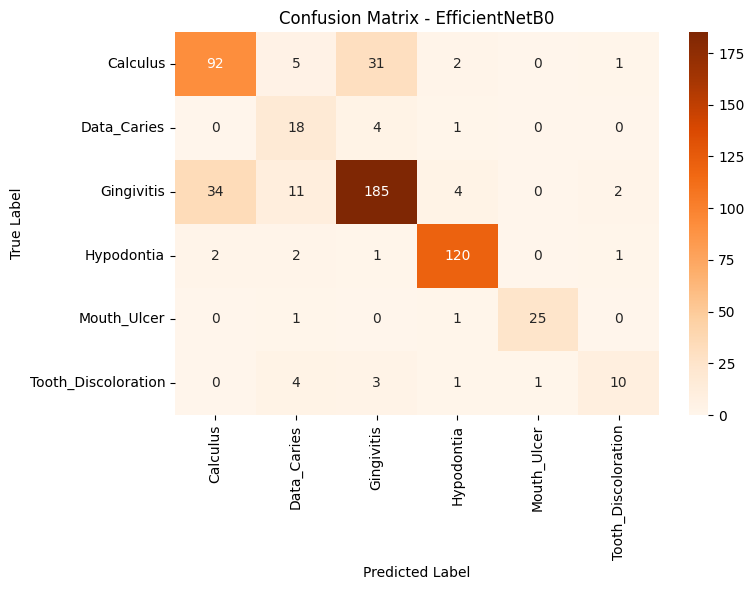

In [ ]:
test_generator_eff.reset()
y_pred_probs_eff = efficientnet_final.predict(test_generator_eff)
y_pred_eff = np.argmax(y_pred_probs_eff, axis=1)
y_true_eff = test_generator_eff.classes

print("Classification Report - EfficientNetB0\n")
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
plt.figure(figsize=(8,6))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetB0')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/cm_efficientnet.png', dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_model, resnet_base = build_transfer_model(ResNet50)

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
callbacks_resnet = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/best_resnet.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_resnet = resnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_resnet
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.5137 - loss: 1.3327 - val_accuracy: 0.6890 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 537ms/step - accuracy: 0.6070 - loss: 0.9336 - val_accuracy: 0.6600 - val_loss: 0.7653 - learning_rate: 0.0010
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 77s 555ms/step - accuracy: 0.6275 - loss: 0.8490 - val_accuracy: 0.6962 - val_loss: 0.6781 - learning_rate: 0.0010
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 538ms/step - accuracy: 0.6376 - loss: 0.7721 - val_accuracy: 0.7107 - val_loss: 0.6438 - learning_rate: 0.0010
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 74s 535ms/step - accuracy: 0.6482 - loss: 0.7196 - val_accuracy: 0.6835 - val_loss: 0.6488 - learning_rate: 0.0010
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 76s 546ms/step - accuracy: 0.6742 - loss: 0.6634 - val_accuracy: 0.7125 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 545ms/step - accuracy: 0.6

In [ ]:
resnet_base.trainable = True

fine_tune_at = 140  # ResNet50 أعمق من EfficientNet، فبنسيب layers أقل قابلة للتدريب نسبيًا
for layer in resnet_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"عدد الـ layers القابلة للتدريب: {sum(1 for l in resnet_base.layers if l.trainable)}")

عدد الـ layers القابلة للتدريب: 35


In [ ]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_resnet_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('/content/best_resnet_finetuned.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history_resnet_ft = resnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=8,
    class_weight=class_weights,
    callbacks=callbacks_resnet_ft
)

Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 111s 627ms/step - accuracy: 0.6419 - loss: 0.6676 - val_accuracy: 0.7378 - val_loss: 0.5794 - learning_rate: 1.0000e-05
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 79s 565ms/step - accuracy: 0.6960 - loss: 0.5182 - val_accuracy: 0.7414 - val_loss: 0.5775 - learning_rate: 1.0000e-05
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 77s 554ms/step - accuracy: 0.7145 - loss: 0.4490 - val_accuracy: 0.7378 - val_loss: 0.5656 - learning_rate: 1.0000e-05
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 79s 567ms/step - accuracy: 0.7509 - loss: 0.3874 - val_accuracy: 0.7432 - val_loss: 0.5540 - learning_rate: 1.0000e-05
Epoch 5/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 78s 559ms/step - accuracy: 0.7615 - loss: 0.3757 - val_accuracy: 0.7505 - val_loss: 0.5314 - learning_rate: 1.0000e-05
Epoch 6/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 80s 550ms/step - accuracy: 0.7657 - loss: 0.3571 - val_accuracy: 0.7505 - val_loss: 0.5309 - learning_rate: 1.0000e-05
Epoch 7/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 79s 566ms/st

In [ ]:
test_loss_res, test_acc_res = resnet_model.evaluate(test_generator_eff)
print(f"\nResNet50 Test Accuracy: {test_acc_res:.4f}")
print(f"ResNet50 Test Loss: {test_loss_res:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 476ms/step - accuracy: 0.7900 - loss: 0.5283

ResNet50 Test Accuracy: 0.7900
ResNet50 Test Loss: 0.5283


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 325ms/step
Classification Report - ResNet50

                     precision    recall  f1-score   support

           Calculus       0.63      0.77      0.69       131
        Data_Caries       0.59      0.74      0.65        23
         Gingivitis       0.85      0.72      0.78       236
         Hypodontia       0.95      0.94      0.94       126
        Mouth_Ulcer       0.92      0.89      0.91        27
Tooth_Discoloration       0.62      0.68      0.65        19

           accuracy                           0.79       562
          macro avg       0.76      0.79      0.77       562
       weighted avg       0.81      0.79      0.79       562



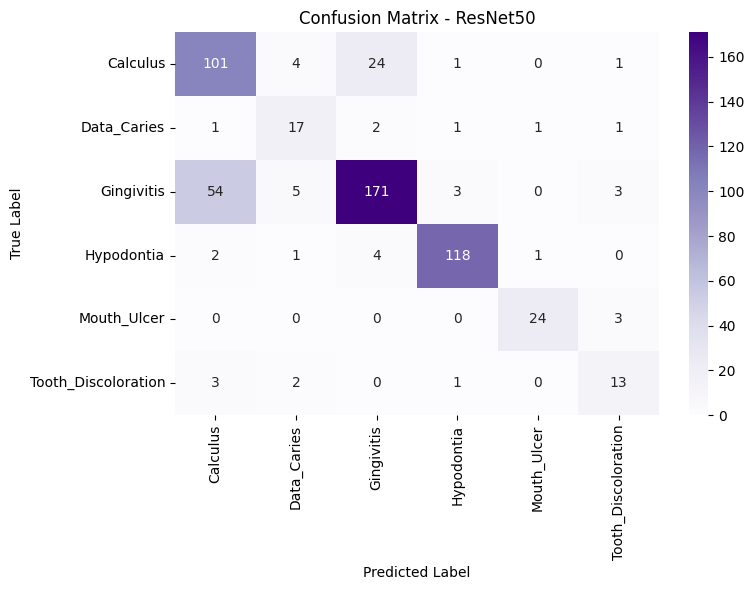

In [ ]:
test_generator_eff.reset()
y_pred_probs_res = resnet_model.predict(test_generator_eff)
y_pred_res = np.argmax(y_pred_probs_res, axis=1)
y_true_res = test_generator_eff.classes

print("Classification Report - ResNet50\n")
print(classification_report(y_true_res, y_pred_res, target_names=class_names))

cm_res = confusion_matrix(y_true_res, y_pred_res)
plt.figure(figsize=(8,6))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet50')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/cm_resnet.png', dpi=150)
plt.show()

In [ ]:
def build_efficientnet_tuned(dense_units=256, dropout_rate=0.4, learning_rate=0.001):
    base = EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(6, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
configs = [
    {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'dense_units': 512, 'dropout_rate': 0.5, 'learning_rate': 0.0005},
    {'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.0001},
]

tuning_results = []

for i, config in enumerate(configs):
    print(f"\n{'='*50}")
    print(f"تجربة {i+1}/3: {config}")
    print('='*50)

    model = build_efficientnet_tuned(**config)

    callbacks_tune = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ]

    history = model.fit(
        train_generator_eff,
        validation_data=val_generator_eff,
        epochs=8,   # عدد أقل هنا عشان نختبر بسرعة، مش تدريب نهائي
        class_weight=class_weights,
        callbacks=callbacks_tune,
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    tuning_results.append({**config, 'best_val_accuracy': val_acc})
    print(f"\nأفضل val_accuracy للتجربة دي: {val_acc:.4f}")

print("\n\n===== ملخص كل التجارب =====")
for r in tuning_results:
    print(r)


تجربة 1/3: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 108s 601ms/step - accuracy: 0.5515 - loss: 1.1552 - val_accuracy: 0.6655 - val_loss: 0.8695
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 513ms/step - accuracy: 0.6661 - loss: 0.7619 - val_accuracy: 0.6998 - val_loss: 0.7309
Epoch 3/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 67s 485ms/step - accuracy: 0.6969 - loss: 0.6475 - val_accuracy: 0.7432 - val_loss: 0.5997
Epoch 4/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 70s 502ms/step - accuracy: 0.7179 - loss: 0.5820 - val_accuracy: 0.7269 - val_loss: 0.6688
Epoch 5/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.7426 - loss: 0.5144 - val_accuracy: 0.7396 - val_loss: 0.5856
Epoch 6/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.7489 - loss: 0.5023 - val_accuracy: 0.7360 - val_loss: 0.5621
Epoch 7/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 70s 506ms/step - accuracy: 0.7547 - loss: 0.4766 - val_accuracy: 0.7649 - val_loss: 0.5254
Epoch 8/8
1

In [ ]:
import shutil
import os

backup_path = '/content/drive/MyDrive/ Oral_Disease_Project/saved_models'
os.makedirs(backup_path, exist_ok=True)

models_to_backup = [
    'best_custom_cnn.keras',
    'best_mobilenet.keras',
    'best_mobilenet_finetuned.keras',
    'best_efficientnet.keras',
    'best_efficientnet_finetuned.keras',
    'best_resnet.keras',
    'best_resnet_finetuned.keras',
]

for m in models_to_backup:
    src = f'/content/{m}'
    if os.path.exists(src):
        shutil.copy(src, f'{backup_path}/{m}')
        print(f"✅ اتنسخ: {m}")
    else:
        print(f"⚠️ مش موجود: {m}")

print("\nكل الموديلات المحفوظة دلوقتي في Drive:")
print(os.listdir(backup_path))

✅ اتنسخ: best_custom_cnn.keras
✅ اتنسخ: best_mobilenet.keras
✅ اتنسخ: best_mobilenet_finetuned.keras
✅ اتنسخ: best_efficientnet.keras
✅ اتنسخ: best_efficientnet_finetuned.keras
✅ اتنسخ: best_resnet.keras
✅ اتنسخ: best_resnet_finetuned.keras

كل الموديلات المحفوظة دلوقتي في Drive:
['best_custom_cnn.keras', 'best_mobilenet.keras', 'best_mobilenet_finetuned.keras', 'best_efficientnet.keras', 'best_efficientnet_finetuned.keras', 'best_resnet.keras', 'best_resnet_finetuned.keras']


In [ ]:
import pandas as pd

comparison_data = {
    'Model': ['Custom CNN', 'MobileNetV2', 'EfficientNetB0', 'ResNet50'],
    'Technique': ['From Scratch', 'Transfer Learning + Fine-tuning',
                  'Transfer Learning (Feature Extraction)', 'Transfer Learning + Fine-tuning'],
    'Test Accuracy': [0.7135, 0.7800, 0.8007, 0.7900],
    'Params (Trainable)': [
        custom_cnn.count_params(),
        mobilenet_model.count_params(),
        efficientnet_final.count_params(),
        resnet_model.count_params()
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['Test Accuracy'] = df_comparison['Test Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_comparison = df_comparison.sort_values('Test Accuracy', ascending=False)
print(df_comparison.to_string(index=False))

df_comparison.to_csv('/content/model_comparison.csv', index=False)

         Model                              Technique Test Accuracy  Params (Trainable)
EfficientNetB0 Transfer Learning (Feature Extraction)        80.07%             4379049
      ResNet50        Transfer Learning + Fine-tuning        79.00%            24113798
   MobileNetV2        Transfer Learning + Fine-tuning        78.00%             2587462
    Custom CNN                           From Scratch        71.35%              457670


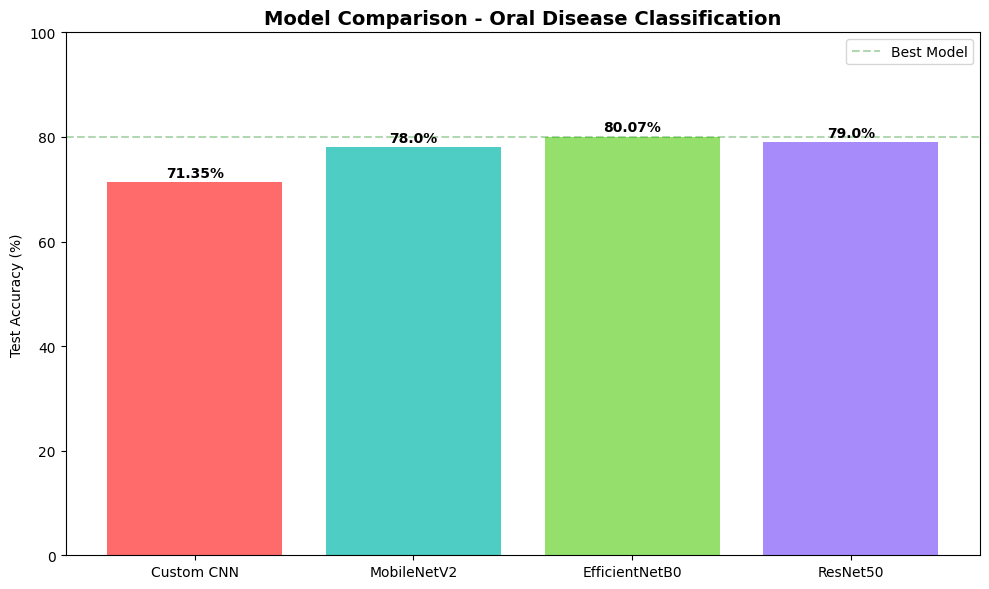

In [ ]:
import matplotlib.pyplot as plt

models_names = ['Custom CNN', 'MobileNetV2', 'EfficientNetB0', 'ResNet50']
accuracies = [71.35, 78.00, 80.07, 79.00]
colors = ['#FF6B6B', '#4ECDC4', '#95E06C', '#A78BFA']

plt.figure(figsize=(10,6))
bars = plt.bar(models_names, accuracies, color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison - Oral Disease Classification', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{acc}%', ha='center', fontweight='bold')

plt.axhline(y=80.07, color='green', linestyle='--', alpha=0.3, label='Best Model')
plt.legend()
plt.tight_layout()
plt.savefig('/content/model_comparison_chart.png', dpi=150)
plt.show()

In [ ]:
analysis_files = [
    'model_comparison.csv',
    'model_comparison_chart.png',
    'cm_custom_cnn.png',
    'cm_mobilenet.png',
    'cm_efficientnet.png',
    'cm_resnet.png',
    'history_custom_cnn.png',
]

analysis_backup = f'{backup_path}/../analysis_outputs'
os.makedirs(analysis_backup, exist_ok=True)

for f in analysis_files:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'{analysis_backup}/{f}')
        print(f"✅ اتنسخ: {f}")
    else:
        print(f"⚠️ مش موجود: {f}")

✅ اتنسخ: model_comparison.csv
✅ اتنسخ: model_comparison_chart.png
✅ اتنسخ: cm_custom_cnn.png
✅ اتنسخ: cm_mobilenet.png
✅ اتنسخ: cm_efficientnet.png
✅ اتنسخ: cm_resnet.png
✅ اتنسخ: history_custom_cnn.png


In [ ]:
import json

# نتأكد إن الموديل النهائي هو أفضل نسخة من EfficientNet
final_model = load_model('/content/best_efficientnet.keras')

# نحفظ ترتيب الفئات كـ JSON عشان نستخدمه بره Colab (في VS Code)
class_names_ordered = list(class_indices.keys())  # بالترتيب الصح من الـ generator
with open('/content/class_names.json', 'w') as f:
    json.dump(class_names_ordered, f, ensure_ascii=False, indent=2)

print("Class names order:", class_names_ordered)

Class names order: ['Calculus', 'Data_Caries', 'Gingivitis', 'Hypodontia', 'Mouth_Ulcer', 'Tooth_Discoloration']


In [ ]:
deployment_path = f'{backup_path}/../deployment'
os.makedirs(deployment_path, exist_ok=True)

shutil.copy('/content/best_efficientnet.keras', f'{deployment_path}/final_model.keras')
shutil.copy('/content/class_names.json', f'{deployment_path}/class_names.json')

print("✅ الموديل النهائي وملف الفئات جاهزين للتحميل من:")
print(deployment_path)
print(os.listdir(deployment_path))

✅ الموديل النهائي وملف الفئات جاهزين للتحميل من:
/content/drive/MyDrive/ Oral_Disease_Project/saved_models/../deployment
['final_model.keras', 'class_names.json']
